<a href="https://colab.research.google.com/github/andysanchez1403-droid/ANDREA-GLZ-SNZ/blob/main/M%C3%89TODO_DE_GALERKIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MÉTOD DE GALERKIN**

In [127]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

Queremos resolver está ecuación:

-u² + u -x = 0


-u² + u = x

sujeta a las condiciones: u(0)=U(1)=0

Analíticamente:

In [82]:
x = sp.symbols('x')
aplha1, alpha2, aplha3 = sp.symbols('alpha1 alpha2 alpha3')

In [83]:
ode = -u(x).diff(x, x) + u(x) + x
sp.dsolve(ode, u(x))

Eq(u(x), C1*exp(-x) + C2*exp(x) - x)

In [84]:
sol= sp.dsolve(ode, ics={u(0): 0, u(1): 0})

In [85]:
sol

Eq(u(x), -x + E*exp(x)/(-1 + exp(2)) - E*exp(-x)/(-1 + exp(2)))

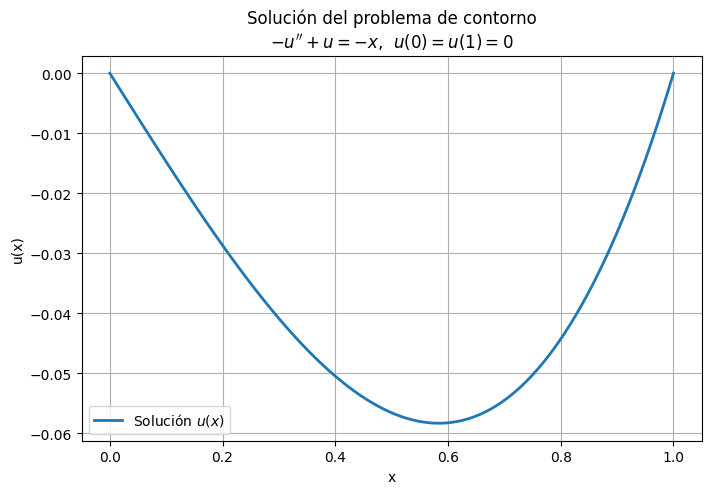

In [87]:
# Convertimos en un arreglo de numpy
u_expr = sol.rhs

u_num = sp.lambdify(x, u_expr, "numpy")

#################
xx = np.linspace(0, 1, 100)
yy = u_num(xx)

plt.figure(figsize=(8,5))
plt.plot(xx, yy, label="Solución $u(x)$", linewidth=2)
plt.title("Solución del problema de contorno\n$-u'' + u = -x$,  $u(0)=u(1)=0$")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.grid(True)
plt.legend()
plt.show()

In [98]:
alpha1, alpha2, alpha3 = sp.symbols('alpha1 alpha2 alpha3')

alpha1 = sp.symbols('alpha1')
alpha2 = sp.symbols('alpha2')
alpha3 = sp.symbols('alpha3')

# Funciones de prueba correctas: sin(iπx)
phi1 = sp.sin(sp.pi*x)
phi2 = sp.sin(2*sp.pi*x)
phi3 = sp.sin(3*sp.pi*x)

u_3 = alpha1*phi1 + alpha2*phi2 + alpha3*phi3

In [99]:
u_2

a*x*(1 - x) + b*x**2*(1 - x)

Definimos el residuo (error) E

In [100]:
sp.diff(u_approx, x, 2) + u_approx - x  # -u'' + u = x


E = -sp.diff(u_approx, x, 2) + u_approx - x
E_simp = sp.simplify(E)

In [101]:
E

alpha1*sin(pi*x) + alpha2*sin(2*pi*x) + alpha3*sin(3*pi*x) - x + pi**2*(alpha1*sin(pi*x) + 4*alpha2*sin(2*pi*x) + 9*alpha3*sin(3*pi*x))

In [102]:
E.simplify()

alpha1*sin(pi*x) + alpha2*sin(2*pi*x) + alpha3*sin(3*pi*x) - x + pi**2*(alpha1*sin(pi*x) + 4*alpha2*sin(2*pi*x) + 9*alpha3*sin(3*pi*x))

Ahora, imponemos las condiciones:

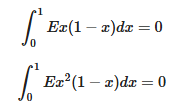

In [93]:
# Esto es CORRECTO (usando phi_j como peso)
eq1 = sp.integrate(E * phi1, (x, 0, 1))
eq2 = sp.integrate(E * phi2, (x, 0, 1))
eq3 = sp.integrate(E * phi3, (x, 0, 1))

In [94]:
eq1

alpha1/2 + pi**2*alpha1/2 - 1/pi

In [95]:
eq2

alpha2/2 + 2*pi**2*alpha2 + 1/(2*pi)

In [96]:
eq3

alpha3/2 + 9*pi**2*alpha3/2 - 1/(3*pi)

In [107]:
sol = sp.solve([eq1, eq2, eq3 ], [alpha1, alpha2, aplha3],  simplify=True) # para igualar  a 0
sol

{alpha1: 2/(pi + pi**3),
 alpha2: -1/(pi + 4*pi**3),
 alpha3: 2/(3*pi + 27*pi**3)}

In [108]:
u_approx = alpha1*phi1 + alpha2*phi2 + alpha3*phi3


In [78]:
u_approx

alpha1*sin(pi*x) + alpha2*sin(2*pi*x) + alpha3*sin(3*pi*x)

In [79]:
u_approx.simplify()

alpha1*sin(pi*x) + alpha2*sin(2*pi*x) + alpha3*sin(3*pi*x)

In [113]:
u_approx_fn = sp.lambdify(x, u_approx, "numpy")

In [115]:
if isinstance(sol, dict):
    u_approx_sol = u_approx.subs(sol)
    print("\nSolución aproximada con valores numéricos:")
    sp.pprint(u_approx_sol)

    # Convertir a float explícitamente
    u_approx_sol_simplified = sp.N(u_approx_sol)
    print("\nSolución numérica simplificada:")
    sp.pprint(u_approx_sol_simplified)
else:
    # Si sol es una lista
    u_approx_sol = u_approx.subs({alpha1: sol[0][0], alpha2: sol[0][1], alpha3: sol[0][2]})


Solución aproximada con valores numéricos:
2⋅sin(π⋅x)   sin(2⋅π⋅x)   2⋅sin(3⋅π⋅x)
────────── - ────────── + ────────────
       3             3              3 
  π + π       π + 4⋅π     3⋅π + 27⋅π  

Solución numérica simplificada:
0.0585688079231089⋅sin(π⋅x) - 0.00786369391449544⋅sin(2⋅π⋅x) + 0.0023624067892 ↪

↪ 5932⋅sin(3⋅π⋅x)


In [118]:
u_exact = x - sp.sinh(x)/sp.sinh(1)
u_approx_fn = sp.lambdify(x, u_approx_sol, 'numpy')
u_exact_fn = sp.lambdify(x, u_exact, 'numpy')

In [121]:
xx = np.linspace(0, 1, 100)
yy_approx = u_approx_fn(xx)
yy_exact = u_exact_fn(xx)


In [122]:
print(f"Valores de prueba - yy_approx[0] = {yy_approx[0]}")
print(f"Tipo: {type(yy_approx[0])}")

Valores de prueba - yy_approx[0] = 0.0
Tipo: <class 'numpy.float64'>


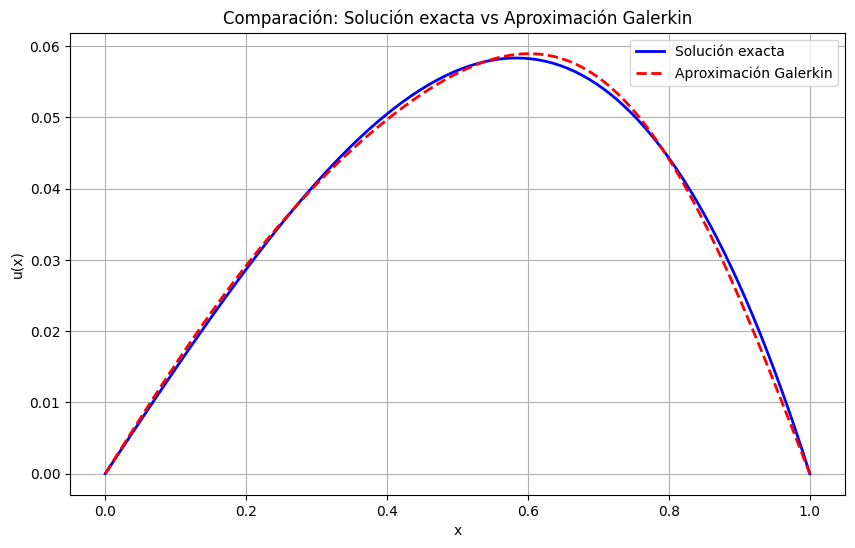

In [123]:
plt.figure(figsize=(10, 6))
plt.plot(xx, yy_exact, 'b-', label='Solución exacta', linewidth=2)
plt.plot(xx, yy_approx, 'r--', label='Aproximación Galerkin', linewidth=2)
plt.title('Comparación: Solución exacta vs Aproximación Galerkin')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.grid(True)
plt.legend()
plt.show()

In [124]:
error = np.abs(yy_exact - yy_approx)
max_error = np.max(error)
rms_error = np.sqrt(np.mean(error**2))

In [125]:
print(f"\nError máximo: {max_error:.2e}")
print(f"Error RMS: {rms_error:.2e}")



Error máximo: 1.98e-03
Error RMS: 8.40e-04


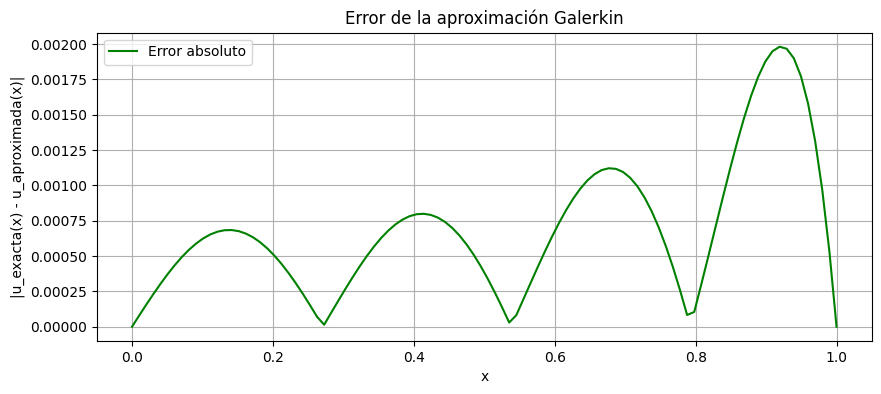

In [126]:
plt.figure(figsize=(10, 4))
plt.plot(xx, error, 'g-', label='Error absoluto')
plt.title('Error de la aproximación Galerkin')
plt.xlabel('x')
plt.ylabel('|u_exacta(x) - u_aproximada(x)|')
plt.grid(True)
plt.legend()
plt.show()